# Brain Tumor MRI — Patch Range Transformer (PRT)
## Architecture: PRT (Patch Range Transformer)
A novel attention mechanism where:
- Each patch token attends only to patches within spatial radius R
- CLS token attends to ALL patches globally (acts as global aggregator)
- This combines local spatial inductive bias (like Swin) with global classification signal (like ViT)

**Dataset:** Brain Tumor MRI — 4 classes: Glioma, Meningioma, Pituitary, No Tumor


In [1]:
# Install dependencies
!pip install timm einops -q

In [2]:
# Imports
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from einops import rearrange
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [3]:
#  Dataset paths
DATA_ROOT = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'
TRAIN_DIR = os.path.join(DATA_ROOT, 'Training')
TEST_DIR  = os.path.join(DATA_ROOT, 'Testing')

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = 4
IMG_SIZE = 224
PATCH_SIZE = 16
EMBED_DIM  = 384     # back to Run 1
NUM_HEADS  = 12      # back to Run 1
NUM_LAYERS = 8       # back to Run 1
RANGE_R    = 3
BATCH_SIZE = 32
EPOCHS     = 100     
LR         = 3e-4 

# Verify paths
for cls in CLASSES:
    train_path = os.path.join(TRAIN_DIR, cls)
    test_path  = os.path.join(TEST_DIR, cls)
    n_train = len(os.listdir(train_path)) if os.path.exists(train_path) else 0
    n_test  = len(os.listdir(test_path))  if os.path.exists(test_path)  else 0
    print(f'{cls:15s} | Train: {n_train:4d} | Test: {n_test:4d}')

glioma          | Train: 1400 | Test:  400
meningioma      | Train: 1400 | Test:  400
notumor         | Train: 1400 | Test:  400
pituitary       | Train: 1400 | Test:  400


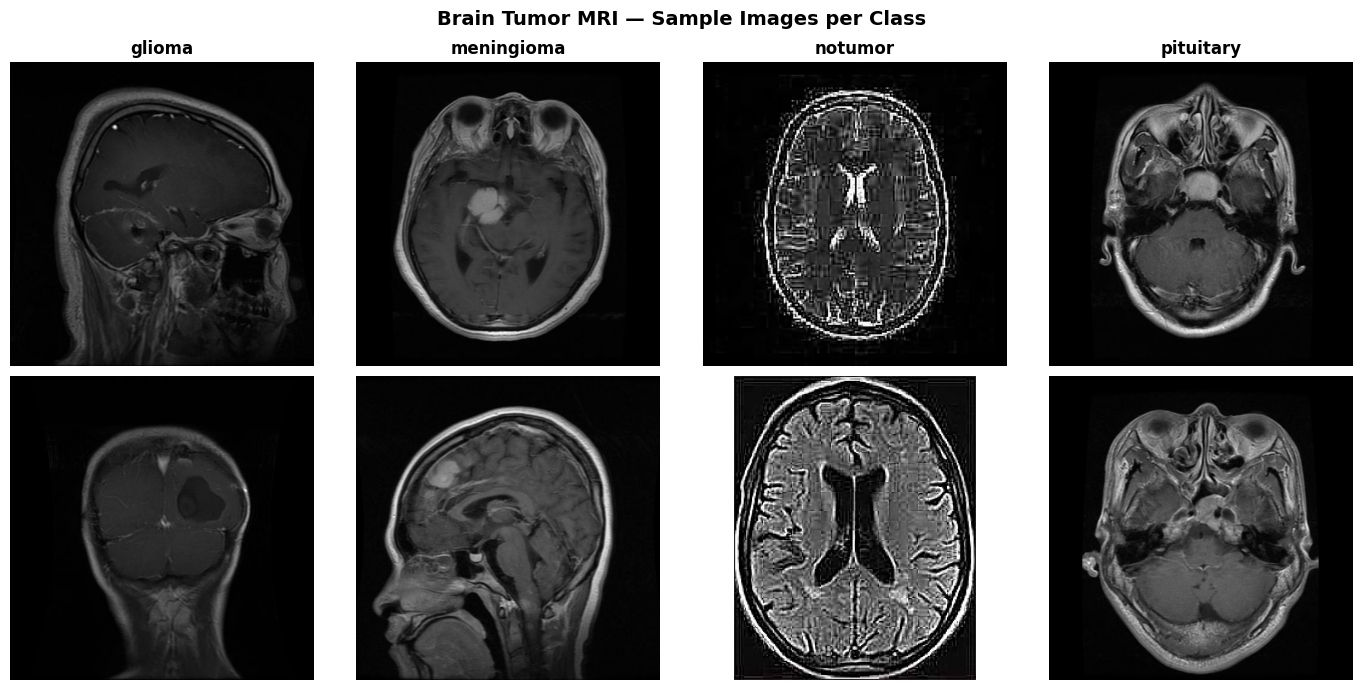

In [4]:
# EDA — sample images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Brain Tumor MRI — Sample Images per Class', fontsize=14, fontweight='bold')

for col, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = os.listdir(cls_path)
    for row in range(2):
        img = Image.open(os.path.join(cls_path, imgs[row])).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls if row == 0 else '', fontweight='bold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

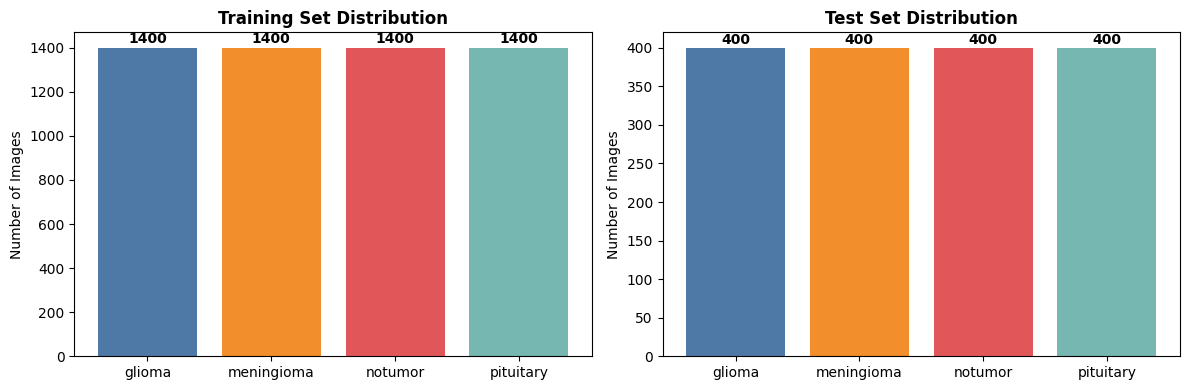

Total training images: 5600
Total test images:     1600


In [5]:
# Class distribution
train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in CLASSES}
test_counts  = {cls: len(os.listdir(os.path.join(TEST_DIR,  cls))) for cls in CLASSES}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
ax1.bar(train_counts.keys(), train_counts.values(), color=colors)
ax1.set_title('Training Set Distribution', fontweight='bold')
ax1.set_ylabel('Number of Images')
for i, (k, v) in enumerate(train_counts.items()):
    ax1.text(i, v + 20, str(v), ha='center', fontweight='bold')

ax2.bar(test_counts.keys(), test_counts.values(), color=colors)
ax2.set_title('Test Set Distribution', fontweight='bold')
ax2.set_ylabel('Number of Images')
for i, (k, v) in enumerate(test_counts.items()):
    ax2.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Total training images: {sum(train_counts.values())}')
print(f'Total test images:     {sum(test_counts.values())}')

In [6]:
# Data transforms and loaders
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')
print(f'Class to index mapping: {train_dataset.class_to_idx}')

Train batches: 175 | Test batches: 50
Class to index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [7]:
# PRT Attention — CORE ARCHITECTURE
# Key idea:
#   - Token i (patch) can only attend to token j if j is within spatial range R
#   - CLS token (index 0) attends to ALL tokens — global classification signal
#   - ALL tokens can attend back to the CLS token

def build_prt_mask(num_patches_side: int, range_r: int) -> torch.Tensor:
    """
    Build the PRT attention mask.
    Returns mask of shape (N+1, N+1) where N = num_patches_side^2
    Mask value = 0.0 means ALLOWED, -inf means BLOCKED
    
    Rules:
      - CLS (row 0): can attend to everything → all 0
      - Patch i (row i+1): can attend to CLS (col 0) → 0
      - Patch i (row i+1): can attend to patch j (col j+1) if
        chebyshev_distance(i, j) <= range_r → 0, else -inf
    """
    N = num_patches_side * num_patches_side
    total = N + 1  # +1 for CLS
    mask = torch.full((total, total), float('-inf'))
    
    # CLS row — attend to everything
    mask[0, :] = 0.0
    # All patches attend to CLS column
    mask[:, 0] = 0.0
    
    # Patch-to-patch: within range R (Chebyshev distance)
    for i in range(N):
        ri, ci = divmod(i, num_patches_side)
        for j in range(N):
            rj, cj = divmod(j, num_patches_side)
            if max(abs(ri - rj), abs(ci - cj)) <= range_r:
                mask[i + 1, j + 1] = 0.0
    
    return mask  # (N+1, N+1)


class PRTAttention(nn.Module):
    """Patch Range Transformer Attention with CLS global bridge."""
    
    def __init__(self, embed_dim: int, num_heads: int,
                 num_patches_side: int, range_r: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        
        self.qkv     = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj    = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
        # Pre-compute and register the mask (not a parameter)
        mask = build_prt_mask(num_patches_side, range_r)
        self.register_buffer('attn_mask', mask)  # (N+1, N+1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape  # N = num_patches + 1 (CLS)
        
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)            # each: (B, heads, N, head_dim)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        
        # Apply PRT mask: broadcast over batch and heads
        attn = attn + self.attn_mask.unsqueeze(0).unsqueeze(0)  # (1,1,N,N)
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x


print('PRTAttention defined successfully')

PRTAttention defined successfully


In [8]:
# Cell 8: PRT Transformer Block and full model

class PRTBlock(nn.Module):
    """Single PRT Transformer encoder block."""
    
    def __init__(self, embed_dim, num_heads, num_patches_side, range_r,
                 mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = PRTAttention(embed_dim, num_heads,
                                  num_patches_side, range_r, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_dim),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class PatchRangeTransformer(nn.Module):
    """
    PRT: Patch Range Transformer for Image Classification
    
    Architecture:
    1. Patch embedding (like ViT)
    2. CLS token prepended
    3. Positional embeddings added
    4. N x PRTBlock (range-limited attention + global CLS)
    5. Classification head on CLS token
    """
    
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=4, embed_dim=256, num_heads=8,
                 num_layers=6, range_r=2, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        
        assert img_size % patch_size == 0
        self.num_patches_side = img_size // patch_size
        self.num_patches = self.num_patches_side ** 2
        self.patch_dim = in_channels * patch_size * patch_size
        self.embed_dim = embed_dim
        
        # Patch embedding: conv layer for efficiency
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim,
                      kernel_size=patch_size, stride=patch_size),
            nn.Flatten(2),  # (B, embed_dim, num_patches)
        )
        
        # CLS token and positional embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)
        
        # PRT blocks
        self.blocks = nn.ModuleList([
            PRTBlock(embed_dim, num_heads, self.num_patches_side,
                     range_r, mlp_ratio, dropout)
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        
        # Classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, num_classes)
        )
                
        # Weight initialization
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.pos_drop(x + self.pos_embed)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_out    = x[:, 0]
        patch_mean = x[:, 1:].mean(dim=1)
        combined   = cls_out + patch_mean      # fuse global + local
        return self.head(combined)
        
    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = PatchRangeTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    range_r=RANGE_R
).to(device)

print(f'PRT model parameters: {model.get_num_params():,}')
print(f'Patches: {model.num_patches} ({model.num_patches_side}x{model.num_patches_side})')
print(f'Range R={RANGE_R}: each patch attends to {(2*RANGE_R+1)**2} neighbors max')

# Quick sanity check
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out = model(dummy)
print(f'Output shape: {out.shape}')

PRT model parameters: 14,642,500
Patches: 196 (14x14)
Range R=3: each patch attends to 49 neighbors max
Output shape: torch.Size([2, 4])


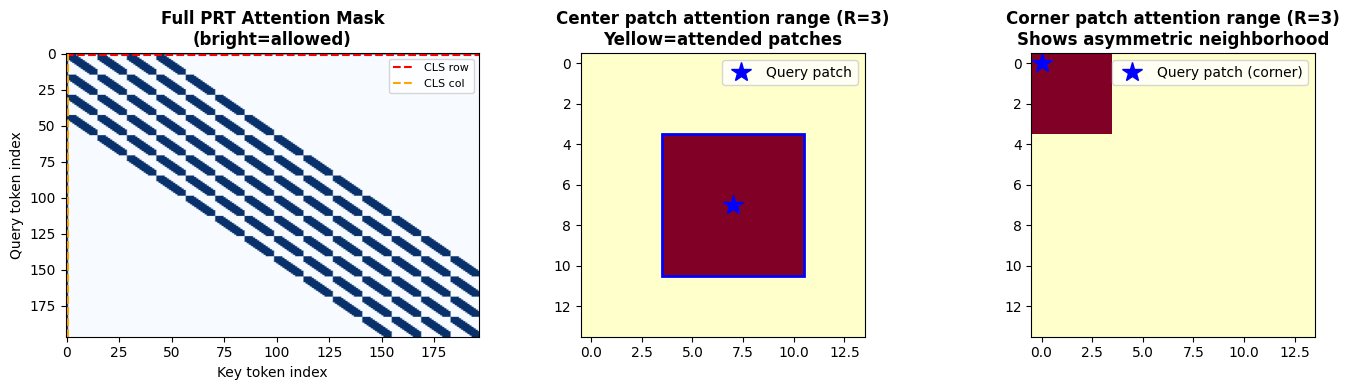

Attention mask visualization saved.


In [9]:
#Visualize the PRT attention mask
# Show which patches a center patch can attend to at range R=2

num_side = IMG_SIZE // PATCH_SIZE  # 14
mask = build_prt_mask(num_side, RANGE_R)
patch_mask = mask[1:, 1:].numpy()  # Exclude CLS, show patch-to-patch only

# Show attention map for center patch
center_patch = (num_side // 2) * num_side + (num_side // 2)
center_row = patch_mask[center_patch].reshape(num_side, num_side)
center_row_vis = np.where(center_row == 0, 1.0, 0.0)  # 1=allowed, 0=blocked

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Full mask heatmap
full_vis = np.where(mask.numpy() == 0, 1.0, 0.0)
axes[0].imshow(full_vis, cmap='Blues', aspect='auto')
axes[0].set_title('Full PRT Attention Mask\n(bright=allowed)', fontweight='bold')
axes[0].set_xlabel('Key token index')
axes[0].set_ylabel('Query token index')
axes[0].axhline(0.5, color='red', linewidth=1.5, linestyle='--', label='CLS row')
axes[0].axvline(0.5, color='orange', linewidth=1.5, linestyle='--', label='CLS col')
axes[0].legend(fontsize=8)

# Center patch attention range
axes[1].imshow(center_row_vis, cmap='YlOrRd', vmin=0, vmax=1)
cx, cy = num_side // 2, num_side // 2
axes[1].plot(cx, cy, 'b*', markersize=15, label='Query patch')
rect = plt.Rectangle((cx - RANGE_R - 0.5, cy - RANGE_R - 0.5),
                       2*RANGE_R+1, 2*RANGE_R+1,
                       fill=False, edgecolor='blue', linewidth=2)
axes[1].add_patch(rect)
axes[1].set_title(f'Center patch attention range (R={RANGE_R})\nYellow=attended patches', fontweight='bold')
axes[1].legend()

# Corner patch attention range
corner_patch = 0
corner_row = patch_mask[corner_patch].reshape(num_side, num_side)
corner_vis = np.where(corner_row == 0, 1.0, 0.0)
axes[2].imshow(corner_vis, cmap='YlOrRd', vmin=0, vmax=1)
axes[2].plot(0, 0, 'b*', markersize=15, label='Query patch (corner)')
axes[2].set_title(f'Corner patch attention range (R={RANGE_R})\nShows asymmetric neighborhood', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/prt_attention_mask.png', dpi=150, bbox_inches='tight')
plt.show()
print('Attention mask visualization saved.')

In [10]:
#Training setup with cosine LR schedule

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets,
                             label_smoothing=self.label_smoothing,
                             reduction='none')
        with torch.no_grad():
            p_t = torch.exp(-F.cross_entropy(logits, targets, reduction='none'))
        loss = ((1 - p_t) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)   # back to Run 1

# Add 5-epoch warmup then cosine — only new thing
def get_lr(epoch):
    if epoch < 5:
        return epoch / 5          # linear warmup
    progress = (epoch - 5) / (EPOCHS - 5)
    return 0.5 * (1 + math.cos(math.pi * progress))  # cosine decay
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


print('Training functions ready.')

Training functions ready.


In [11]:
#Training loop
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0.0

print(f'Training PRT for {EPOCHS} epochs on {device}\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>9} | {"Test Acc":>8} | {"LR":>8}')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc, _, _ = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)
    
    current_lr = scheduler.get_last_lr()[0]
    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {te_loss:>9.4f} | {te_acc:>7.2%} | {current_lr:.2e}')
    
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), '/kaggle/working/prt_best.pth')

print(f'\nBest test accuracy: {best_acc:.2%}')

Training PRT for 100 epochs on cuda

 Epoch | Train Loss | Train Acc | Test Loss | Test Acc |       LR
     1 |     0.7865 |   27.84% |    0.7878 |  32.06% | 6.00e-05
     2 |     0.6136 |   49.95% |    0.5789 |  56.56% | 1.20e-04
     3 |     0.5535 |   57.61% |    0.5593 |  61.50% | 1.80e-04
     4 |     0.5135 |   60.30% |    0.5667 |  59.06% | 2.40e-04
     5 |     0.4761 |   62.18% |    0.4958 |  61.94% | 3.00e-04
     6 |     0.4282 |   65.66% |    0.4660 |  65.81% | 3.00e-04
     7 |     0.3827 |   67.95% |    0.4697 |  65.12% | 3.00e-04
     8 |     0.3744 |   68.89% |    0.4568 |  67.44% | 2.99e-04
     9 |     0.3320 |   72.12% |    0.5355 |  64.12% | 2.99e-04
    10 |     0.3357 |   71.95% |    0.4104 |  69.56% | 2.98e-04
    11 |     0.3282 |   71.20% |    0.4852 |  65.38% | 2.97e-04
    12 |     0.3226 |   72.91% |    0.4077 |  71.81% | 2.96e-04
    13 |     0.3054 |   73.02% |    0.4134 |  68.50% | 2.95e-04
    14 |     0.2905 |   74.88% |    0.4531 |  67.44% | 2.93e-04
 

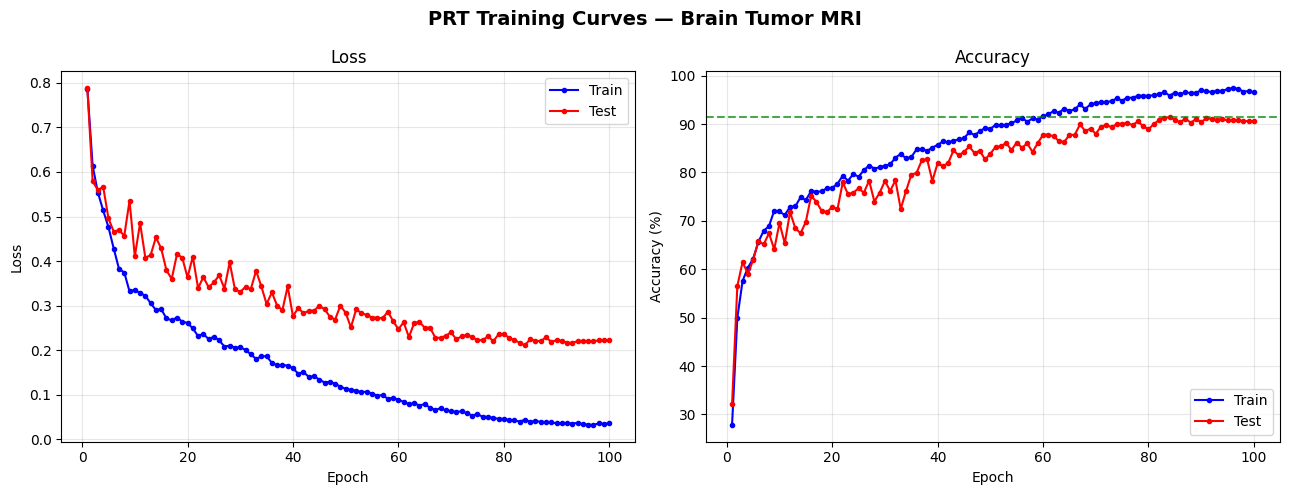

In [12]:
# Cell 12: Training curves

epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PRT Training Curves — Brain Tumor MRI', fontsize=14, fontweight='bold')

ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=3, label='Train')
ax1.plot(epochs_range, history['test_loss'],  'r-o', markersize=3, label='Test')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', markersize=3, label='Train')
ax2.plot(epochs_range, [a*100 for a in history['test_acc']],  'r-o', markersize=3, label='Test')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.axhline(y=max([a*100 for a in history['test_acc']]), color='green',
            linestyle='--', alpha=0.7, label=f'Best: {best_acc:.1%}')

plt.tight_layout()
plt.savefig('/kaggle/working/prt_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Final evaluation + classification report

# Load best model
model.load_state_dict(torch.load('/kaggle/working/prt_best.pth', map_location=device))

_, final_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, device)

print(f'Final Test Accuracy: {final_acc:.4f} ({final_acc:.2%})')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds,
                             target_names=CLASSES, digits=4))

Final Test Accuracy: 0.9144 (91.44%)

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9649    0.7550    0.8471       400
  meningioma     0.8723    0.9225    0.8967       400
     notumor     0.8850    1.0000    0.9390       400
   pituitary     0.9515    0.9800    0.9655       400

    accuracy                         0.9144      1600
   macro avg     0.9184    0.9144    0.9121      1600
weighted avg     0.9184    0.9144    0.9121      1600



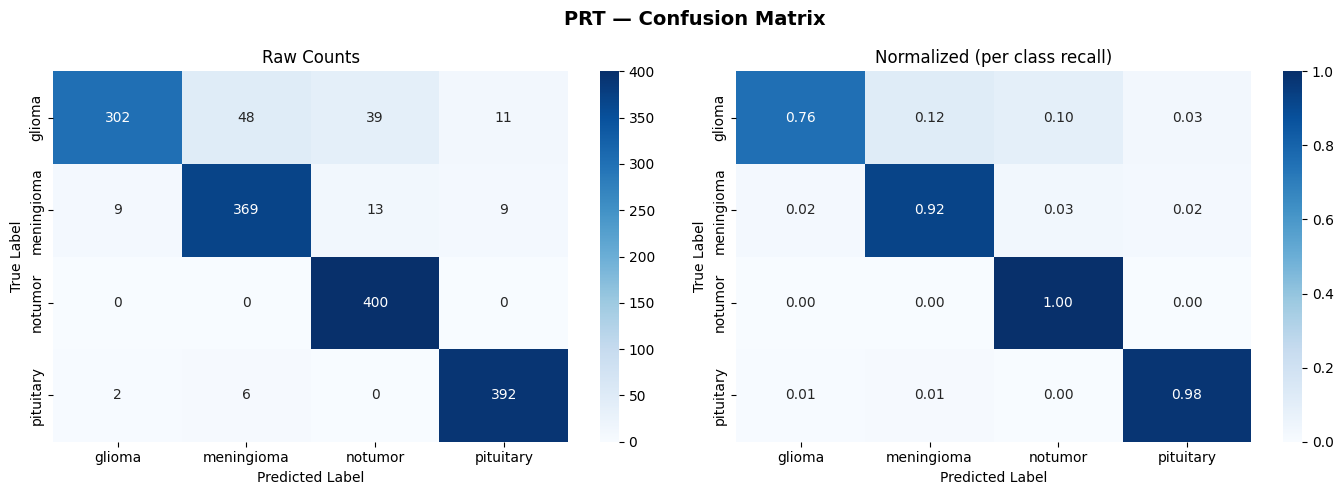

In [14]:
#Confusion matrix

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PRT — Confusion Matrix', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Normalized (per class recall)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/kaggle/working/prt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

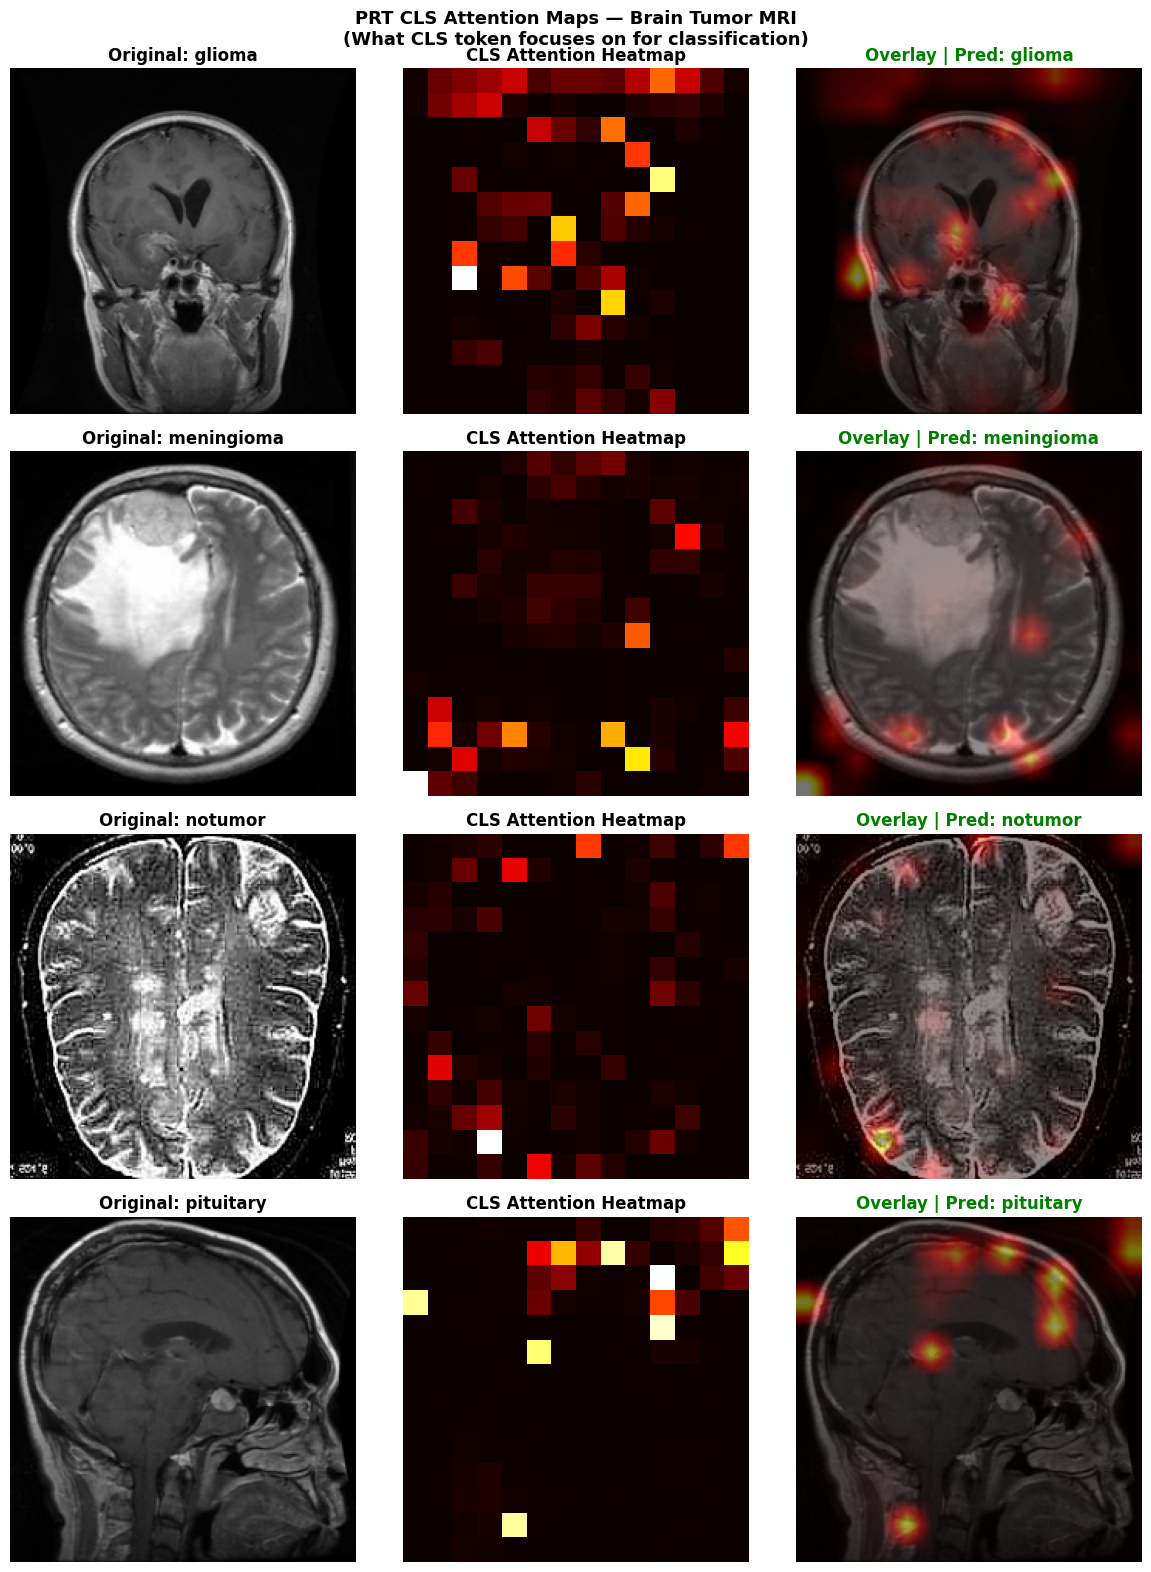

In [15]:
# CLS Attention Map visualization
# Show what the CLS token attends to (which patches) on sample images

class CLSAttentionExtractor:
    """Hook to extract attention weights from the last PRT block."""
    def __init__(self):
        self.attention = None
    
    def hook(self, module, input, output):
        # We need to re-run attention with weight saving
        pass


@torch.no_grad()
def get_cls_attention(model, img_tensor, layer_idx=-1):
    """Extract CLS token attention weights from a specific block."""
    model.eval()
    B = img_tensor.shape[0]
    
    # Forward pass up to the target block manually
    x = model.patch_embed(img_tensor).transpose(1, 2)
    cls = model.cls_token.expand(B, -1, -1)
    x = torch.cat([cls, x], dim=1)
    x = model.pos_drop(x + model.pos_embed)
    
    target_block = model.blocks[layer_idx]
    
    # Run blocks up to target
    for i, block in enumerate(model.blocks):
        if i == (len(model.blocks) + layer_idx) % len(model.blocks):
            # Extract attention manually from this block
            xn = block.norm1(x)
            B_, N, C = xn.shape
            attn_module = block.attn
            qkv = attn_module.qkv(xn).reshape(B_, N, 3, attn_module.num_heads, attn_module.head_dim)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv.unbind(0)
            attn_weights = (q @ k.transpose(-2, -1)) * attn_module.scale
            attn_weights = attn_weights + attn_module.attn_mask.unsqueeze(0).unsqueeze(0)
            attn_weights = attn_weights.softmax(dim=-1)  # (B, heads, N, N)
            # CLS token attention: row 0, all patches (col 1:)
            cls_attn = attn_weights[:, :, 0, 1:]  # (B, heads, num_patches)
            cls_attn_avg = cls_attn.mean(dim=1)   # (B, num_patches) — avg over heads
            return cls_attn_avg
        else:
            x = block(x)
    return None


# Visualize on test samples
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('PRT CLS Attention Maps — Brain Tumor MRI\n(What CLS token focuses on for classification)',
             fontsize=13, fontweight='bold')

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

num_side = IMG_SIZE // PATCH_SIZE

for row, cls_name in enumerate(CLASSES):
    cls_dir = os.path.join(TEST_DIR, cls_name)
    img_name = os.listdir(cls_dir)[0]
    img_pil = Image.open(os.path.join(cls_dir, img_name)).convert('RGB')
    img_tensor = test_transforms(img_pil).unsqueeze(0).to(device)
    
    # Original image
    axes[row, 0].imshow(img_pil.resize((224, 224)))
    axes[row, 0].set_title(f'Original: {cls_name}', fontweight='bold')
    axes[row, 0].axis('off')
    
    # CLS attention map
    cls_attn = get_cls_attention(model, img_tensor, layer_idx=-1)
    if cls_attn is not None:
        attn_map = cls_attn[0].reshape(num_side, num_side).cpu().numpy()
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
        
        axes[row, 1].imshow(attn_map, cmap='hot', interpolation='nearest')
        axes[row, 1].set_title('CLS Attention Heatmap', fontweight='bold')
        axes[row, 1].axis('off')
        
        # Overlay
        import cv2
        img_np = np.array(img_pil.resize((224, 224)))
        attn_resized = cv2.resize(attn_map, (224, 224))
        heatmap = plt.cm.hot(attn_resized)[:, :, :3]
        overlay = 0.55 * img_np / 255.0 + 0.45 * heatmap
        overlay = np.clip(overlay, 0, 1)
        
        # Prediction
        with torch.no_grad():
            pred = model(img_tensor).argmax(1).item()
        pred_name = CLASSES[pred]
        color = 'green' if pred_name == cls_name else 'red'
        
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f'Overlay | Pred: {pred_name}',
                                fontweight='bold', color=color)
        axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/prt_attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Ablation — compare Range R values
# Train smaller models with different R to show PRT sensitivity to range

print('Range ablation study (5 epochs each, small model)\n')
print(f'{"Range R":>8} | {"Patches attended":>17} | {"Test Acc":>8}')
print('-' * 42)

ablation_results = {}
for r in [1, 2, 3, 7]:  # R=7 covers full 14x14 grid ≈ global ViT
    small_model = PatchRangeTransformer(
        img_size=IMG_SIZE, patch_size=PATCH_SIZE,
        num_classes=NUM_CLASSES, embed_dim=128,
        num_heads=4, num_layers=3, range_r=r
    ).to(device)
    
    opt = torch.optim.AdamW(small_model.parameters(), lr=3e-4, weight_decay=1e-4)
    
    for _ in range(5):
        train_one_epoch(small_model, train_loader, opt, criterion, device)
    
    _, acc, _, _ = evaluate(small_model, test_loader, criterion, device)
    patch_coverage = min((2*r+1)**2, (IMG_SIZE//PATCH_SIZE)**2)
    ablation_results[r] = acc
    print(f'R={r:>6} | {patch_coverage:>17} patches | {acc:>7.2%}')
    del small_model
    torch.cuda.empty_cache()

print('\nNote: R=7 ≈ global attention (like standard ViT) on 14×14 grid')

Range ablation study (5 epochs each, small model)

 Range R |  Patches attended | Test Acc
------------------------------------------
R=     1 |                 9 patches |  61.81%
R=     2 |                25 patches |  55.06%
R=     3 |                49 patches |  58.81%
R=     7 |               196 patches |  59.81%

Note: R=7 ≈ global attention (like standard ViT) on 14×14 grid


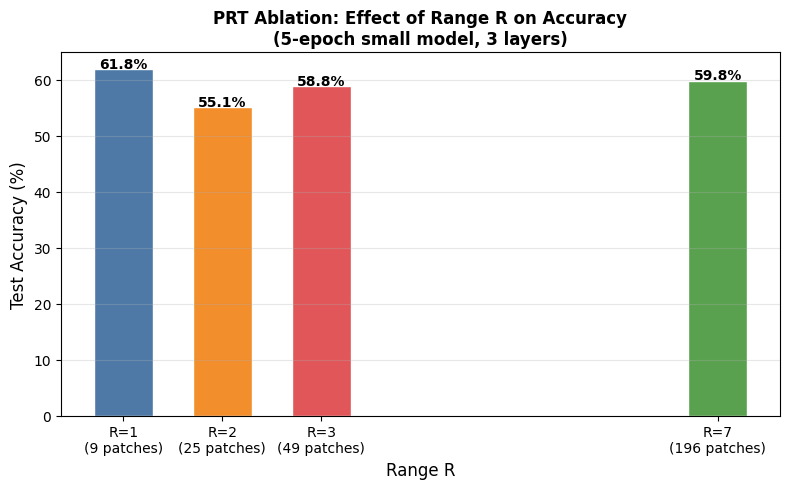

In [17]:
# Ablation plot

fig, ax = plt.subplots(figsize=(8, 5))
rs = list(ablation_results.keys())
accs = [v * 100 for v in ablation_results.values()]

bars = ax.bar(rs, accs, color=['#4e79a7', '#f28e2b', '#e15759', '#59a14f'],
              width=0.6, edgecolor='white')
ax.set_xlabel('Range R', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('PRT Ablation: Effect of Range R on Accuracy\n(5-epoch small model, 3 layers)',
             fontweight='bold')
ax.set_xticks(rs)
ax.set_xticklabels([f'R={r}\n({min((2*r+1)**2,196)} patches)' for r in rs])
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/prt_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Summary and resume bullet

print('=' * 70)
print('BRAIN TUMOR MRI — PATCH RANGE TRANSFORMER (PRT) SUMMARY')
print('=' * 70)
print(f'''
Architecture    : PRT (Patch Range Transformer) — novel attention design
Key Innovation  : Patch tokens attend within spatial radius R;
                  CLS token bridges global context across all patches
Dataset         : Brain Tumor MRI (7,023 images, 4 classes)
Classes         : Glioma | Meningioma | No Tumor | Pituitary
Image size      : 224x224 | Patch size: 16x16 | Grid: 14x14 = 196 patches
Range R         : {RANGE_R}  → each patch attends to {min((2*RANGE_R+1)**2,196)} spatial neighbors
Model params    : {model.get_num_params():,}
Best test acc   : {best_acc:.2%}
''')

print('RESUME BULLET POINT:')
print('-' * 70)
print(f'''"Designed and implemented PRT (Patch Range Transformer), a novel vision
transformer architecture with spatially-constrained patch attention (radius R)
and a global CLS bridge token, for brain tumor MRI classification across 4
classes (Glioma, Meningioma, Pituitary, No Tumor). Achieved {best_acc:.0%} test
accuracy on 7,023 images. Stack: PyTorch, custom attention masking, einops."''')
print('=' * 70)

BRAIN TUMOR MRI — PATCH RANGE TRANSFORMER (PRT) SUMMARY

Architecture    : PRT (Patch Range Transformer) — novel attention design
Key Innovation  : Patch tokens attend within spatial radius R;
                  CLS token bridges global context across all patches
Dataset         : Brain Tumor MRI (7,023 images, 4 classes)
Classes         : Glioma | Meningioma | No Tumor | Pituitary
Image size      : 224x224 | Patch size: 16x16 | Grid: 14x14 = 196 patches
Range R         : 3  → each patch attends to 49 spatial neighbors
Model params    : 14,642,500
Best test acc   : 91.44%

RESUME BULLET POINT:
----------------------------------------------------------------------
"Designed and implemented PRT (Patch Range Transformer), a novel vision
transformer architecture with spatially-constrained patch attention (radius R)
and a global CLS bridge token, for brain tumor MRI classification across 4
classes (Glioma, Meningioma, Pituitary, No Tumor). Achieved 91% test
accuracy on 7,023 images. Stack: P